## RunModelsWithMedianEmbedding
This script:
- Reads the per-buurt median embedding (from pickle files produced by script 3)
- Joins with the CBS **SES-WOA** deprivation target
- Fits and compares several regression models (XGBoost, LinearRegression, Ridge, SVR, k-NN) using
  cross-validation with hyperparameter tuning, and keeps the best by CV R²
- Tests out-of-sample performance on a held-out 20% test set
- Saves the best model for reuse

**Reporting — the SES-WOA target is a continuous score.** SES-WOA (CBS table 86092NED) is a continuous
socio-economic status score. We report the **raw-score R²** on the SES-WOA total score as the metric of
explained variance.

`RANDOM_STATE = 42` and the 80/20 split are fixed for reproducibility.

### Dependencies
**Prerequisites:** Script 3 (creates per-buurt embedding summaries).

**Inputs:**
- `data/processed/per_buurt_embedding_summaries/median_embedding.pkl` - per-buurt median embeddings (from script 3)
- CBS SES-WOA target (table 86092NED), fetched/cached by `amsterdam_data.get_ses_woa()` to `ses_file`
- Amsterdam buurt boundaries (via `amsterdam_data.get_amsterdam_buurten()`) - for visualisation only
- `street_data.h5` (via `h5_filename`) - downloaded panorama locations, overlaid on the sanity-check map only
- `clustering_functions.py` - imports `RANDOM_STATE`, `embedding_statistic`

**Outputs:**
- `data/models/best_model.joblib` - best pipeline (`StandardScaler` -> regressor) of those compared,
  selected by CV R², with metadata

**Used by:** Scripts 5, 6, 7, 8, 9b

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*glibc.*")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing
import joblib
import h5py
import geopandas as gpd

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import spearmanr
from xgboost import XGBRegressor

from model_evaluation import compute_metrics


def evaluate_model(y_true, y_pred, column, num_in_class=None, num_areas=None,
                   plot=True, plot_collectively=False, ax=None):
    """Compute regression metrics (via compute_metrics) and optionally plot true vs predicted."""
    metrics = compute_metrics(y_true, y_pred)

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        plt.xlabel(f"True {column}")
        plt.ylabel(f"Predicted {column}")
        plt.title(f"{column}")
        plt.grid(True)
        plt.show()

    if plot_collectively and ax is not None:
        ax.scatter(y_true, y_pred, alpha=0.7)
        ax.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{column}: \n{num_in_class} images\n {num_areas} buurten", fontsize=15)
        ax.grid(True)
        ax.text(
            0.01, 0.99,
            f'R² = {metrics["R2"]:.2f}, RMSE = {metrics["RMSE"]:.2f}',
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            horizontalalignment='left')

    return metrics

In [2]:
from directory_filepaths import *
from clustering_functions import RANDOM_STATE, embedding_statistic
from amsterdam_data import get_ses_woa, get_amsterdam_buurten

The PRIMARY target is the continuous SES-WOA total score (`TARGET_COL`).

The embedding aggregation statistic (mean/median/max) is defined centrally in `clustering_functions.py`.

In [3]:
var_to_predict = TARGET_COL  # 'ses_woa_score' (continuous; PRIMARY)

# Aggregation statistic is defined centrally in clustering_functions.py
statistic = embedding_statistic
print(f"Predicting '{var_to_predict}' using '{statistic}' embedding aggregation")

Predicting 'ses_woa_score' using 'median' embedding aggregation


### Get SES-WOA deprivation data

In [4]:
ses = get_ses_woa()  # buurtcode, ses_woa_score, ses_welvaart, ses_opleiding, ses_arbeidsverleden
ses

,buurtcode,ses_woa_score,ses_welvaart,ses_opleiding,ses_arbeidsverleden
0,BU00340101,-0.400,-0.241,-0.061,-0.099
1,BU00340102,-0.145,-0.031,-0.038,-0.076
2,BU00340201,-0.072,-0.052,-0.027,0.007
3,BU00340202,0.230,0.116,0.056,0.058
4,BU00340203,-0.371,-0.198,-0.089,-0.084
...,...,...,...,...,...
641,BU03840501,-0.521,-0.325,0.125,-0.322
642,BU03840502,0.428,0.120,0.195,0.113
643,BU03840503,-0.901,-0.558,-0.030,-0.313
644,BU03840701,0.822,0.328,0.275,0.219


In [5]:
ses.info()

<class 'pandas.DataFrame'>
RangeIndex: 646 entries, 0 to 645
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   buurtcode            646 non-null    str    
 1   ses_woa_score        646 non-null    float64
 2   ses_welvaart         646 non-null    float64
 3   ses_opleiding        646 non-null    float64
 4   ses_arbeidsverleden  646 non-null    float64
dtypes: float64(4), str(1)
memory usage: 31.7 KB


### Sanity check: map SES-WOA score
Quick choropleth to verify the deprivation data looks sensible (lower scores = more deprived).
Small black points overlay the locations where we currently have downloaded panoramas (read from
`street_data.h5`), so we can eyeball imagery coverage against the deprivation pattern.

Found 839 buuten objects and 646 burten with deprivation data


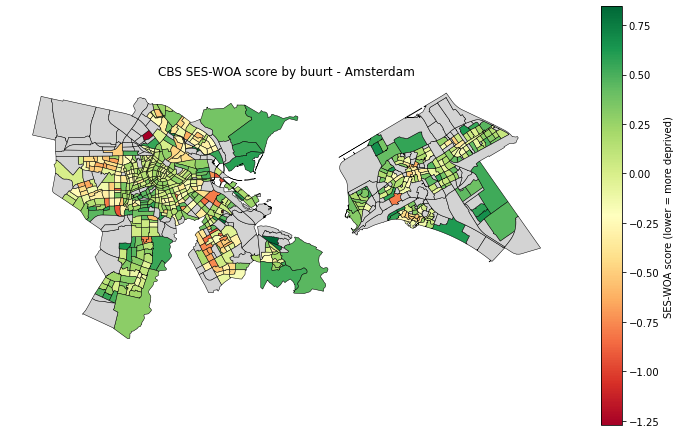

In [6]:
buurten = get_amsterdam_buurten()  # EPSG:28992
print(f"Found {len(buurten)} buuten objects and {len(ses)} burten with deprivation data")
buurten_ses = buurten.merge(ses, on=JOIN_KEY, how='left')

# Locations where we currently have downloaded imagery (any of the 4 cardinal crops
# present). Plotted as small points purely to sanity-check coverage against the
# deprivation choropleth; they are not meant to obscure it.
pano_points = None
if os.path.exists(h5_filename):
    with h5py.File(h5_filename, "r") as f:
        has_image = f["images_present"][:].any(axis=1)  # (N,) any crop downloaded
        lat = f["latitude"][:][has_image]
        lon = f["longitude"][:][has_image]
    pano_points = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(lon, lat),
        crs="EPSG:4326").to_crs(buurten_ses.crs)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
buurten_ses.plot(
    column='ses_woa_score',
    cmap='RdYlGn',  # red = low score (more deprived), green = high score (less deprived)
    legend=True,
    legend_kwds={'label': 'SES-WOA score (lower = more deprived)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey'},
    edgecolor='black',   # buurt outlines
    linewidth=0.5,
    ax=ax)
#if pano_points is not None:
#    pano_points.plot(
#        ax=ax, markersize=0.5, color='black', alpha=0.3,
#        label=f'Downloaded panoramas (n={len(pano_points)})')
#    ax.legend(loc='upper left', markerscale=6, framealpha=0.9)
ax.set_title('CBS SES-WOA score by buurt - Amsterdam')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Sanity check: distribution of panoramas per buurt
Check how evenly we are sampling buurts

Found 641 buurten with at least 1 panorama
Median panoramas per buurt: 66.0, mean: 78.1


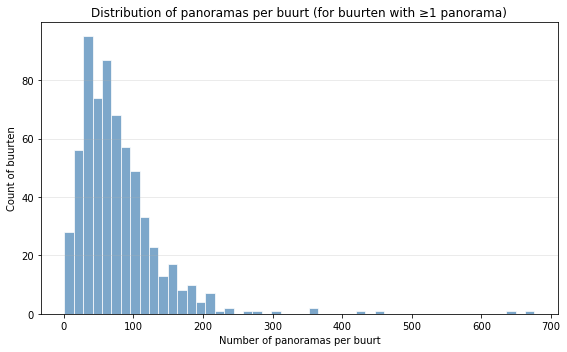

In [7]:
# Histogram of panoramas per buurt (for buurten with at least 1 panorama)
if pano_points is not None:
    pano_buurt = gpd.sjoin(
        pano_points, buurten[[JOIN_KEY, "geometry"]], how="inner", predicate="within"
    )
    n_panos_ser = pano_buurt.groupby(JOIN_KEY).size().rename("n_panos")
    n_panos_df = n_panos_ser.reset_index()
    print(f"Found {len(n_panos_df)} buurten with at least 1 panorama")
    print(f"Median panoramas per buurt: {n_panos_df['n_panos'].median()}, mean: {n_panos_df['n_panos'].mean():.1f}")
    plt.figure(figsize=(8, 5))
    plt.hist(n_panos_df['n_panos'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    plt.xlabel('Number of panoramas per buurt')
    plt.ylabel('Count of buurten')
    plt.title('Distribution of panoramas per buurt (for buurten with ≥1 panorama)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

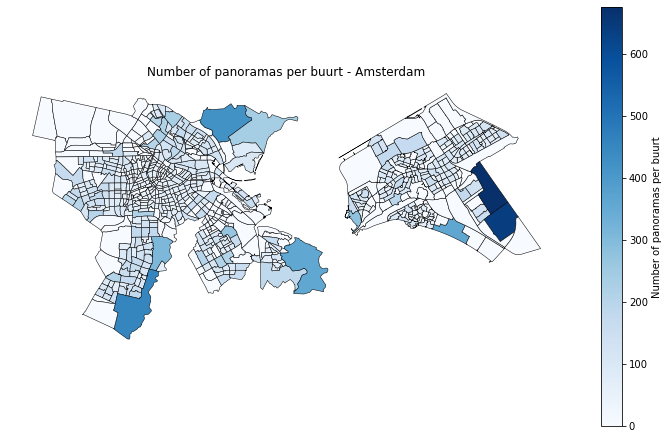

In [8]:
# Map of the number of panoramas per buurt (for buurten with at least 1 panorama)
if pano_points is not None:
    buurten_pano = buurten.merge(n_panos_df, on=JOIN_KEY, how='left')
    buurten_pano['n_panos'] = buurten_pano['n_panos'].fillna(0).astype(int)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    buurten_pano.plot(
        column='n_panos',
        cmap='Blues',
        legend=True,
        legend_kwds={'label': 'Number of panoramas per buurt', 'shrink': 0.6},
        missing_kwds={'color': 'lightgrey'},
        edgecolor='black',
        linewidth=0.5,
        ax=ax)
    ax.set_title('Number of panoramas per buurt - Amsterdam')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

### Get embedding data

In [9]:
embedding_pkl = os.path.join(data_dir, "per_buurt_embedding_summaries", f"{statistic}_embedding.pkl")
big_summary_df = pd.read_pickle(embedding_pkl)

big_summary_df_with_ses = pd.merge(left=big_summary_df, right=ses[[JOIN_KEY, 'ses_woa_score']], on=JOIN_KEY)

print(f"Buurten with both embeddings and SES-WOA data: {len(big_summary_df_with_ses)} / {len(ses)}")

Buurten with both embeddings and SES-WOA data: 641 / 646


In [10]:
print(f"Buurten with both embeddings and SES-WOA data: {len(big_summary_df_with_ses)} / {len(ses)}")

Buurten with both embeddings and SES-WOA data: 641 / 646


### Split the data into 80% training, 20% testing

In [11]:
X = np.stack(big_summary_df_with_ses[f"{statistic}_embedding"].values)
y = big_summary_df_with_ses[var_to_predict].values

# -------------------------
# Split data into training and test sets
# -------------------------
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, np.arange(X.shape[0]), test_size=0.2, random_state=RANDOM_STATE)
print(f"Training points: {X_train.shape[0]}, Test points: {X_test.shape[0]}")

Training points: 512, Test points: 129


### Perform model selection and hyper-parameter tuning using the 80% training data:

We compare several regression models and keep whichever scores the highest cross-validated R².
The problem is **high-dimensional and small-n** (≈512 embedding dimensions vs ≈336 training buurten,
with dense, correlated CLIP features), which motivates the choice of comparators:

- **XGBoost** — gradient-boosted trees; a strong non-linear baseline that captures interactions between
  embedding dimensions without manual feature engineering.
- **LinearRegression** — plain OLS, included as a deliberately naive baseline; because features outnumber
  training rows it is underdetermined here, so it shows what *unregularised* linear fitting buys (likely little).
- **Ridge** — L2-regularised linear regression, the *proper* linear baseline: it handles the p > n,
  collinear-feature regime gracefully and answers "how far does a well-behaved linear map get us?".
- **SVR (RBF kernel)** — a non-tree non-linear model that tends to excel in high-dimensional, small-sample
  settings and exploits the smooth geometry of the embedding space where axis-aligned trees are weakest.
- **k-NN regression** — predicts from the nearest buurten in embedding space, directly testing the
  hypothesis that streetscapes with similar embeddings share similar SES.

All pipelines start with `StandardScaler` (essential for Ridge, SVR and k-NN; harmless for the trees).
Model selection uses R² because, on a single fixed target, it ranks models identically to RMSE while
being directly interpretable; absolute-error metrics (RMSE/MAE) and the cross-comparable NRMSE are still
reported at test time via `compute_metrics`.

In [12]:
# Define model pipelines and parameter grids
# Each entry: (name, pipeline, param_grid). Every pipeline begins with StandardScaler:
# essential for the linear / kernel / distance models below, harmless for the trees.
# See the markdown above for why each model is included.
model_configs = [
    # Gradient-boosted trees: strong non-linear baseline, captures feature interactions.
    ("XGBoost", Pipeline([
        ('scaler', StandardScaler()),
        ('reg', XGBRegressor(
            objective='reg:squarederror',  # minimise squared error (standard for regression)
            random_state=RANDOM_STATE,     # reproducible results
            n_jobs=1,                      # single-threaded: let GridSearchCV own the parallelism across fits
            verbosity=0))]),               # suppress XGBoost's own logging
     {
      'reg__n_estimators': [100, 300],         # number of boosting rounds (more = more complex)
      'reg__max_depth': [3, 6, 10],            # max tree depth (controls model complexity)
      'reg__learning_rate': [0.01, 0.1, 0.3],  # step size shrinkage (lower = slower but often better)
      'reg__subsample': [0.8, 1.0],            # fraction of training rows used per tree (< 1 adds regularisation)
     }),

    # Plain OLS: deliberately naive baseline (underdetermined here, p > n); no hyperparameters.
    ("LinearRegression", Pipeline([
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())]),
     {}),

    # Ridge: L2-regularised linear, the proper linear baseline for the p > n / collinear regime.
    ("Ridge", Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(random_state=RANDOM_STATE))]),
     {
      'reg__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0],  # L2 strength (larger = more shrinkage)
     }),

    # SVR (RBF): non-tree non-linear model that suits high-dimensional, small-sample data.
    ("SVR", Pipeline([
        ('scaler', StandardScaler()),
        ('reg', SVR(kernel='rbf'))]),
     {
      'reg__C': [1.0, 10.0, 100.0],            # inverse regularisation strength
      'reg__gamma': ['scale', 'auto'],         # RBF kernel width
      'reg__epsilon': [0.01, 0.1],             # width of the no-penalty tube
     }),

    # k-NN: predicts from the nearest buurten in embedding space (similarity hypothesis).
    ("KNN", Pipeline([
        ('scaler', StandardScaler()),
        ('reg', KNeighborsRegressor(n_jobs=1))]),  # single-threaded: GridSearchCV owns the parallelism
     {
      'reg__n_neighbors': [5, 10, 20],         # neighbourhood size (larger = smoother)
      'reg__weights': ['uniform', 'distance'], # equal vs distance-weighted averaging
     }),
]

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ncores = min(multiprocessing.cpu_count() - 1, 100)

best_model = None
best_score = -np.inf
best_model_name = None
best_params = {}
cv_results = []  # one row per model, for the summary table below

print(f"Training {len(model_configs)} model(s) using {ncores} cores")

for name, pipeline, param_grid in model_configs:
    # Calculate fits for progress reporting
    n_fits = 1
    for vals in param_grid.values():
        n_fits *= len(vals)
    n_fits *= cv.n_splits
    print(f"\nTraining: {name} ({n_fits} fits)...")

    # Main grid search code:
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2', n_jobs=ncores, verbose=1)
    grid.fit(X_train, y_train)

    print(f"  CV mean R² = {grid.best_score_:.3f}")
    print(f"  Best params: {grid.best_params_}")

    # Record this model's best-candidate CV R² (mean ± std across folds) for the summary table.
    cv_results.append({
        "model": name,
        "cv_r2_mean": grid.best_score_,
        "cv_r2_std": grid.cv_results_["std_test_score"][grid.best_index_],
        "best_params": grid.best_params_,
    })

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_model_name = name
        best_params = grid.best_params_.copy()

print(f"\nBest model: {best_model_name} (CV R² = {best_score:.3f})")
print(f"Best hyperparameters: {best_params}")

# Compute CV NRMSE for the best model (RMSE / std(y_true) per fold, then average)
# This uses the same approach as scripts 7, 8, and 9b for comparability.
from sklearn.base import clone
nrmse_scores = []
for train_ix, val_ix in cv.split(X_train):
    fold_model = clone(best_model)
    fold_model.fit(X_train[train_ix], y_train[train_ix])
    y_val_pred = fold_model.predict(X_train[val_ix])
    fold_rmse = np.sqrt(mean_squared_error(y_train[val_ix], y_val_pred))
    nrmse_scores.append(fold_rmse / np.std(y_train[val_ix]))

cv_nrmse = np.mean(nrmse_scores)
print(f"CV mean NRMSE = {cv_nrmse:.3f}")

Training 5 model(s) using 11 cores

Training: XGBoost (180 fits)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/opt/homebrew/anaconda3/envs/streetview-deprivation-amsterdam/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  CV mean R² = 0.358
  Best params: {'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 300, 'reg__subsample': 0.8}

Training: LinearRegression (5 fits)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
  CV mean R² = -1.092
  Best params: {}

Training: Ridge (25 fits)...


Fitting 5 folds for each of 5 candidates, totalling 25 fits
  CV mean R² = 0.361
  Best params: {'reg__alpha': 100.0}

Training: SVR (60 fits)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


  CV mean R² = 0.468
  Best params: {'reg__C': 10.0, 'reg__epsilon': 0.1, 'reg__gamma': 'scale'}

Training: KNN (30 fits)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


  CV mean R² = 0.251
  Best params: {'reg__n_neighbors': 5, 'reg__weights': 'distance'}

Best model: SVR (CV R² = 0.468)
Best hyperparameters: {'reg__C': 10.0, 'reg__epsilon': 0.1, 'reg__gamma': 'scale'}
CV mean NRMSE = 0.727


### CV R² summary table
The cross-validated R² of each candidate model (mean ± std across the 5 folds, at its best
hyperparameters), sorted best-first. The top row is the model selected and saved above.

In [13]:
# Summarise the CV R² of every candidate model, best-first. The "selected" flag marks the
# model that was kept and saved above (the highest CV mean R²).
cv_summary = (
    pd.DataFrame(cv_results)
    .sort_values("cv_r2_mean", ascending=False)
    .reset_index(drop=True))
cv_summary["selected"] = cv_summary["model"] == best_model_name
cv_summary = cv_summary[["model", "cv_r2_mean", "cv_r2_std", "selected", "best_params"]]

print(f"Cross-validated R² by model ({cv.n_splits}-fold CV on the 80% training set):")
cv_summary.round(3)

Cross-validated R² by model (5-fold CV on the 80% training set):


,model,cv_r2_mean,cv_r2_std,selected,best_params
0,SVR,0.468,0.091,True,"{'reg__C': 10.0, 'reg__epsilon': 0.1, 'reg__ga..."
1,Ridge,0.361,0.105,False,{'reg__alpha': 100.0}
2,XGBoost,0.358,0.038,False,"{'reg__learning_rate': 0.1, 'reg__max_depth': ..."
3,KNN,0.251,0.114,False,"{'reg__n_neighbors': 5, 'reg__weights': 'dista..."
4,LinearRegression,-1.092,0.434,False,{}


In [14]:
# Save the best model
model_dir = os.path.join("../data/models")
os.makedirs(model_dir, exist_ok=True)

bundle = {
    "model": best_model,
    "name": best_model_name,
    "cv_score_r2": float(best_score),
    "cv_nrmse": float(cv_nrmse),
    "best_params": best_params,
}

model_path = os.path.join(model_dir, "best_model.joblib")
joblib.dump(bundle, model_path)
print(f"The best model is {best_model_name}")
print(f"Saved model to {model_path}")

The best model is SVR
Saved model to ../data/models/best_model.joblib


## Test out-of-sample performance of ‘best’ model
by training on the full 80% training data and testing on the 20% which hasn’t been used during
training or hyper-parameter optimisation.

We report the **raw-score R²** on the held-out test set as the metric of explained variance.

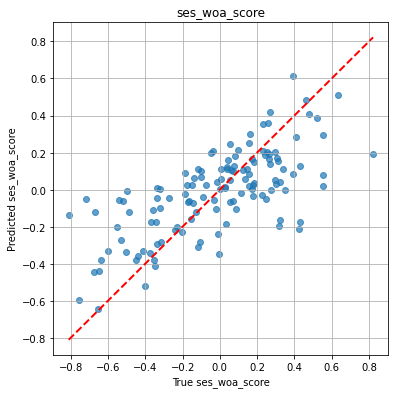

Test set metrics:
  raw-score R² (PRIMARY): 0.489
  RMSE: 0.241
  NRMSE: 0.715
  MAE: 0.185
  Spearman_rank_corr: 0.686


In [15]:
# Predict on held-out test data
y_pred_test = best_model.predict(X_test)

# Evaluate using the function defined above
test_metrics = evaluate_model(
    y_pred=y_pred_test,
    y_true=y_test,
    column=var_to_predict,
    plot=True)

print("Test set metrics:")
print(f"  raw-score R² (PRIMARY): {test_metrics['R2']:.3f}")
for k, v in test_metrics.items():
    if k != 'R2':
        print(f"  {k}: {v:.3f}")

## Diagnostics


In [16]:
# ---------------------------------------------------------------------------
# Build per-buurt CV prediction table (all buurten, leave-one-fold-out).
# ---------------------------------------------------------------------------
from sklearn.model_selection import cross_val_predict

# CV predictions across the full labelled set using the same fold scheme as the grid search.
y_cv_pred = cross_val_predict(best_model, X, y, cv=cv)

# Panorama counts per buurt via spatial join of the already-loaded pano_points.
if pano_points is not None:
    pano_buurt = gpd.sjoin(
        pano_points, buurten[[JOIN_KEY, "geometry"]], how="inner", predicate="within"
    )
    n_panos_ser = pano_buurt.groupby(JOIN_KEY).size().rename("n_panos")
else:
    n_panos_ser = pd.Series(dtype=int, name="n_panos")

diag = pd.DataFrame({
    JOIN_KEY:  big_summary_df_with_ses[JOIN_KEY].values,
    "y_true":  y,
    "y_pred":  y_cv_pred,
})
diag["residual"]     = diag["y_true"] - diag["y_pred"]
diag["abs_residual"] = diag["residual"].abs()
diag = diag.merge(n_panos_ser, on=JOIN_KEY, how="left")
diag["n_panos"] = diag["n_panos"].fillna(0).astype(int)
print(f"diag: {len(diag)} buurten, CV R² = {r2_score(diag['y_true'], diag['y_pred']):.3f}")
diag.head()

diag: 641 buurten, CV R² = 0.478


,buurtcode,y_true,y_pred,residual,abs_residual,n_panos
0,BU00340101,-0.400,-0.116503,-0.283497,0.283497,36
1,BU00340102,-0.145,-0.256367,0.111367,0.111367,109
2,BU00340201,-0.072,0.026076,-0.098076,0.098076,48
3,BU00340202,0.230,-0.136671,0.366671,0.366671,44
4,BU00340203,-0.371,-0.190521,-0.180479,0.180479,16


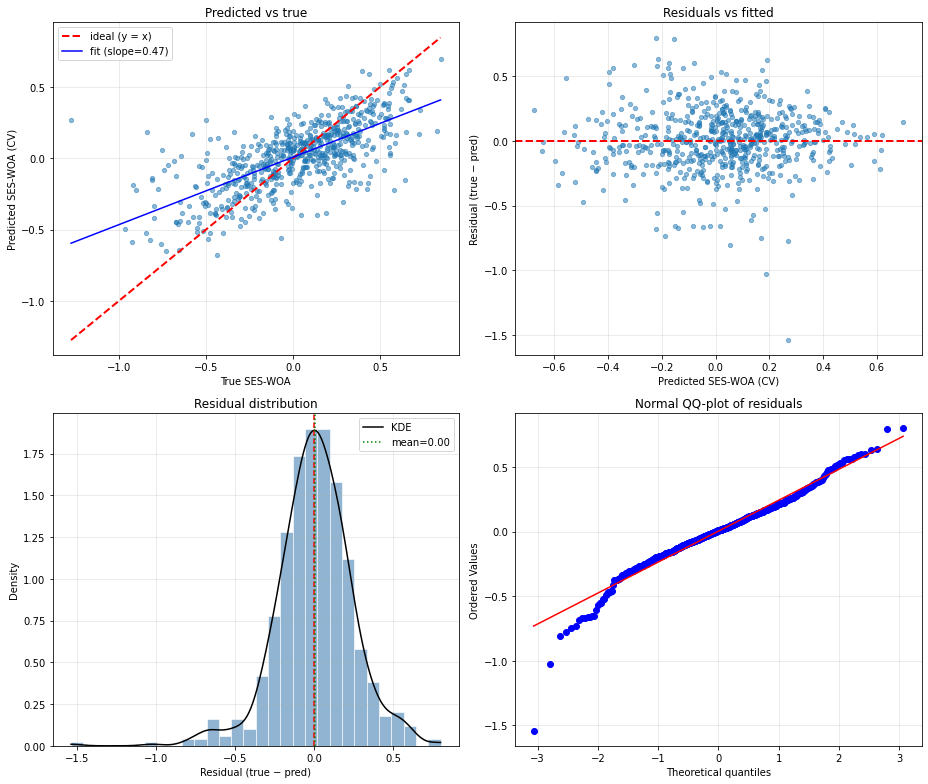

In [17]:
# ---------------------------------------------------------------------------
# Error-distribution diagnostics (CV predictions over all buurten).
# ---------------------------------------------------------------------------
from scipy import stats

resid = diag["residual"].values
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# (a) Predicted vs true, with the identity line and a least-squares fit.
ax = axes[0, 0]
ax.scatter(diag["y_true"], diag["y_pred"], alpha=0.5, s=18)
lims = [min(diag["y_true"].min(), diag["y_pred"].min()),
        max(diag["y_true"].max(), diag["y_pred"].max())]
ax.plot(lims, lims, "r--", lw=2, label="ideal (y = x)")
slope, intercept = np.polyfit(diag["y_true"], diag["y_pred"], 1)
ax.plot(np.array(lims), slope * np.array(lims) + intercept, "b-", lw=1.5,
        label=f"fit (slope={slope:.2f})")
ax.set_xlabel("True SES-WOA"); ax.set_ylabel("Predicted SES-WOA (CV)")
ax.set_title("Predicted vs true"); ax.legend(); ax.grid(alpha=0.3)

# (b) Residual vs fitted — bias trends / heteroscedasticity.
ax = axes[0, 1]
ax.scatter(diag["y_pred"], resid, alpha=0.5, s=18)
ax.axhline(0, color="r", ls="--", lw=2)
ax.set_xlabel("Predicted SES-WOA (CV)"); ax.set_ylabel("Residual (true − pred)")
ax.set_title("Residuals vs fitted"); ax.grid(alpha=0.3)

# (c) Residual distribution (histogram + KDE).
ax = axes[1, 0]
ax.hist(resid, bins=30, density=True, alpha=0.6, color="steelblue", edgecolor="white")
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, stats.gaussian_kde(resid)(xs), "k-", lw=1.5, label="KDE")
ax.axvline(0, color="r", ls="--", lw=1.5)
ax.axvline(resid.mean(), color="green", ls=":", lw=1.5, label=f"mean={resid.mean():.2f}")
ax.set_xlabel("Residual (true − pred)"); ax.set_ylabel("Density")
ax.set_title("Residual distribution"); ax.legend(); ax.grid(alpha=0.3)

# (d) Normal QQ-plot of residuals.
ax = axes[1, 1]
stats.probplot(resid, dist="norm", plot=ax)
ax.set_title("Normal QQ-plot of residuals"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

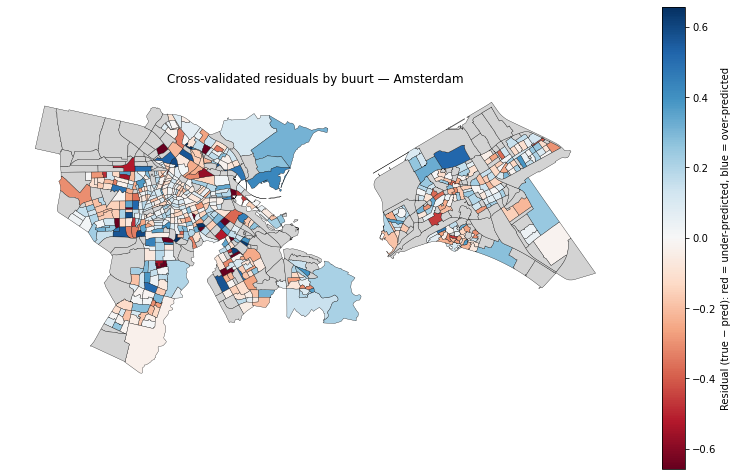

Worst-predicted buurten (largest |residual|):
 buurtcode                  buurtnaam  y_true  y_pred  residual  n_panos
BU0363BB03     Minervahaven-Noordoost  -1.273   0.268    -1.541      102
BU0363MN07 Sportpark Middenmeer-Noord  -0.840   0.186    -1.026       81
BU0363TC03          Amsterdamse Poort  -0.753   0.055    -0.808      114
BU0363KK06                 Kop Zuidas   0.581  -0.221     0.802       62
BU0363NE05            Buiksloterbreek   0.639  -0.154     0.793       34
BU03840303                Beukenhorst  -0.502   0.271    -0.773       10
BU0363KP05                    Vivaldi  -0.578   0.169    -0.747       51
BU0363FM06        Johan Jongkindbuurt  -0.919  -0.187    -0.732       25
BU03840503          Holland Park Zuid  -0.901  -0.220    -0.681       17
BU0363MB03             Parooldriehoek  -0.811  -0.140    -0.671       12
BU0363MH04             Baaibuurt-West  -0.717  -0.048    -0.669       52
BU0363NG02            Elzenhagen-Zuid  -0.644   0.017    -0.661      111


In [18]:
# ---------------------------------------------------------------------------
# Map of the residuals + the worst-predicted buurten.
# ---------------------------------------------------------------------------
from matplotlib.colors import TwoSlopeNorm

buurten_resid = buurten.merge(diag, on=JOIN_KEY, how="left")
# Clip the colour scale at the 98th percentile of |residual| so a few extremes don't
# wash out the rest of the map; centre the diverging scale on 0.
vmax = float(np.nanpercentile(diag["abs_residual"], 98))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(1, 1, figsize=(11, 11))
buurten_resid.plot(
    column="residual", cmap="RdBu", norm=norm, legend=True,
    legend_kwds={"label": "Residual (true − pred): red = under-predicted, blue = over-predicted",
                 "shrink": 0.6},
    missing_kwds={"color": "lightgrey"},   # unscored buurten: no model coverage
    edgecolor="black", linewidth=0.3, ax=ax)
ax.set_title("Cross-validated residuals by buurt — Amsterdam")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Worst-predicted buurten (largest |residual|), with imagery support and name — a
# starting point for eyeballing *why* (atypical land use, sparse imagery, etc.).
name_col = "buurtnaam" if "buurtnaam" in buurten.columns else JOIN_KEY
worst = (diag.merge(buurten[[JOIN_KEY, name_col]].drop_duplicates(JOIN_KEY), on=JOIN_KEY, how="left")
         .sort_values("abs_residual", ascending=False)
         .head(12)[[JOIN_KEY, name_col, "y_true", "y_pred", "residual", "n_panos"]])
print("Worst-predicted buurten (largest |residual|):")
print(worst.round(3).to_string(index=False))